# Energy Budget

## Definitions

There are four types of energy (per unit mass) that we need to keep track of in the fluid:

1. $I = c_v T$ is the **internal energy** *(valid for an ideal gas, see e.g. {cite:t}`Vallis:bigbook2`)* -- this is a measure of the disorganized molecular-scale motion in the fluid
2. $\Phi = g z$ is the gravitational **potential energy**
3. $L = L_v q$ is the **latent energy** associated with the evaporated water in the air ($L_v$ is the latent heat of vaporization and $q$ is the specific humidity)
4. $K = \frac{1}{2} \left(u^2 + v^2 + w^2 \right)$ is the **kinetic energy** of organized motion of the fluid

We'll define the **total energy** per unit mass in the atmosphere as

\begin{align*}
E &= I + \Phi + L + K \\
&= c_v T + gz + L_v q + \frac{1}{2} \left(u^2 + v^2 + w^2 \right) 
\end{align*}

## Budget equations for energy components

### Potential energy

### Latent energy

### Internal energy

### Kinetic energy

## A total energy equation and global conservation

After some work and cancellation of various conversion terms:

$$ \frac{DE}{Dt} = -\alpha \nabla \cdot \left( \vec{v} p \right) - \alpha \nabla \cdot \vec{F}_{rad} + D_h $$

with $D_h = c_p D_T + L_v D_q$ the net surface enthalpy flux and $\vec{F}_{rad}$ the radiative flux.

## Alternate form and Moist Static Energy

We can rewrite the first law of thermodynamics as

\begin{align*}
dQ &= dI + p d\alpha \\
&= dI + d(p\alpha) - \alpha dp \\
&= d(c_v T + RT) - \alpha dp \\
&= d(c_p T ) - \alpha dp 
\end{align*}

where $c_p T$ is refered to as the **sensible energy** $S$

Using this, we can define another form of total energy

$$ \mathcal{E} = S + \Phi + L + K $$

and we'll find it useful to define the **moist static energy** $m$ as the first three terms of $\mathcal{E}$:

$$ m = S + \Phi + L = c_p T + g z + L_v q $$

We'll see from the data that $K$ is typically a small fraction of $\mathcal{E}$ so is often ignored in the total energy budget, and we will talk instead about fluxes of moist static energy rather than fluxes of total energy.

## Merdional energy transport

Write the zonal- and time-averaged energy budget in pressure coordinates and flux form:

$$ \frac{\partial}{\partial t} [\overline{\mathcal{E}}] = -\frac{1}{a \cos\phi} \frac{\partial}{\partial \phi} \left( [\overline{v\mathcal{E}}] \cos\phi \right) -\frac{\partial}{\partial p} \left( [\overline{\omega \mathcal{E}}] \right) + g \left[ \frac{\partial \overline{\vec{F}_{rad}}}{\partial p} \right] + [\overline{D_h}]$$

and we can decompose the meridional energy flux into its components:

$$ [\overline{v\mathcal{E}}] = c_p [\overline{vT}] + g [\overline{vz}] + L_v [\overline{vq}] + [\overline{vK}]$$

Finally we can decompose each component into mean meridional, stationary eddy, and transient eddy terms, e.g.

$$ [\overline{vT}] = [\overline{v}][\overline{T}] + [\overline{v^*} \overline{T^*}] + [\overline{v^\prime T^\prime}] $$

and likewise for the other components.

## The observed energy budget

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from arraylake import Client as alClient
from dask.distributed import Client as dClient

In [2]:
alclient = alClient()
alclient.login()

Successfully refreshed tokens! Token stored at /network/rit/home/br546577/.arraylake/token.json

╭───────────────────────────────────────────────── User Details ──────────────────────────────────────────────────╮
│ Name: None None                                                                                                 │
│ Email: brose@albany.edu                                                                                         │
│ Id: 42b3a5b8-e618-4e14-aba8-632532f16692                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [4]:
repo = alclient.get_repo("earthmover-public/era5")
session = repo.readonly_session("main")
pressure_spatial = xr.open_zarr(session.store, group="pressure/spatial", chunks={})
pressure_spatial

<xarray.Dataset> Size: 327TB
Dimensions:         (valid_time: 756048, pressure_level: 13, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-03-31...
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    sdor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    slor            (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    lsm             (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    z_sfc           (latitude, longitude) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    pv              (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    r               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    t               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    w               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    z               (valid_time, pressure_level, latitude, longitude) float32 41TB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for s...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-05T13:36 GRIB to CDM+CF via cfgrib-0....

In [5]:
# ## Option 1: run this on a laptop
# ##  Comment out this cell if using option 2
# dclient = dClient()
# dclient

In [6]:
## Option 2: If running this notebook on jupyterlab.its.albany.edu, uncomment and run this cell
##  This sets up a cluster of workers to parallelize the calculations

from dask_jobqueue import SLURMCluster

cluster = SLURMCluster(cores=64, # size of a single job -- typically one node of the HPC cluster
                       memory="374GB",  # the max memory on the 64-core burst-daes nodes, I believe
                       walltime="02:00:00",
                       queue="burst-daes",
                      )

cluster.scale(1)
dclient = dClient(cluster)
dclient

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://169.226.65.153:8787/status,
Dashboard: http://169.226.65.153:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://169.226.65.153:20751,Workers: 0
Dashboard: http://169.226.65.153:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [7]:
def bracket(data):
    return data.mean(dim='longitude', skipna=True)

def star(data):
    return data - bracket(data)

def bar(data):
    return data.mean(dim="valid_time", skipna=True)

def prime(data):
    return data - bar(data)

def global_mean(data):
    return data.weighted(np.cos(np.deg2rad(data.latitude))).mean(dim=('latitude','longitude'), skipna=True)

In [8]:
#  Now do the whole year
interval = "2021"

In [9]:
v = pressure_spatial.v.sel(valid_time=interval)
T = pressure_spatial.t.sel(valid_time=interval)

vbar = bar(v)
vbracket = bracket(v)
vbarbracket = bracket(vbar)

Tbar = bar(T)
Tbracket = bracket(T)
Tbarbracket = bar(Tbracket)

In [10]:
%%time
Tbar_global = global_mean(Tbar).compute()  # we subtract the global mean everywhere to avoid large cancellations

/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 12.66 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 2min 53s, sys: 13.2 s, total: 3min 6s
Wall time: 6min 51s


In [11]:
vT = bar(bracket(v*(T - Tbar_global)))
vT_transient = bracket(bar(prime(v)*prime(T)))
vT_stationary = bracket(star(vbar) * star(Tbar))
vT_mmc = vbarbracket * bracket(Tbar - Tbar_global)

vT

<xarray.DataArray (pressure_level: 13, latitude: 721)> Size: 75kB
dask.array<mean_agg-aggregate, shape=(13, 721), dtype=float64, chunksize=(1, 721), chunktype=numpy.ndarray>
Coordinates:
  * pressure_level  (pressure_level) float64 104B 1e+03 925.0 ... 100.0 50.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Attributes: (12/22)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_latitudeOfFirstGridPointInDegrees:   90.0
    GRIB_latitudeOfLastGridPointInDegrees:    -90.0
    GRIB_longitudeOfFirstGridPointInDegrees:  0.0
    GRIB_longitudeOfLastGridPointInDegrees:   359.75
    GRIB_missingValue:                        3.4028234663852886e+38
    GRIB_totalNumber:                         0

In [12]:
sensible_heat_flux = {}

In [13]:
%%time
sensible_heat_flux[r'total $[\overline{vT}]$'] = vT.compute()

/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 25.91 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 6min 50s, sys: 27.3 s, total: 7min 17s
Wall time: 13min 57s


In [14]:
%%time
sensible_heat_flux[r'transient eddies $[\overline{v^\prime T^\prime}]$'] = vT_transient.compute()

/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 28.21 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 12min 12s, sys: 36.8 s, total: 12min 49s
Wall time: 24min 4s


In [15]:
%%time
sensible_heat_flux[r'stationary eddies $[\overline{v}^* \overline{T}^*]$'] = vT_stationary.compute()

/network/rit/lab/snowclus/pixi/aug26/.pixi/envs/default/lib/python3.14/site-packages/distributed/client.py:3429: UserWarning: Sending large graph of size 25.29 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 5min 53s, sys: 23.8 s, total: 6min 17s
Wall time: 14min 9s


In [16]:
%%time
sensible_heat_flux[r'mean meridional circulation $[\overline{v}][\overline{T} - \overline{T}_{global}]$'] = vT_mmc.compute()

CPU times: user 5min 45s, sys: 23.7 s, total: 6min 8s
Wall time: 13min 54s


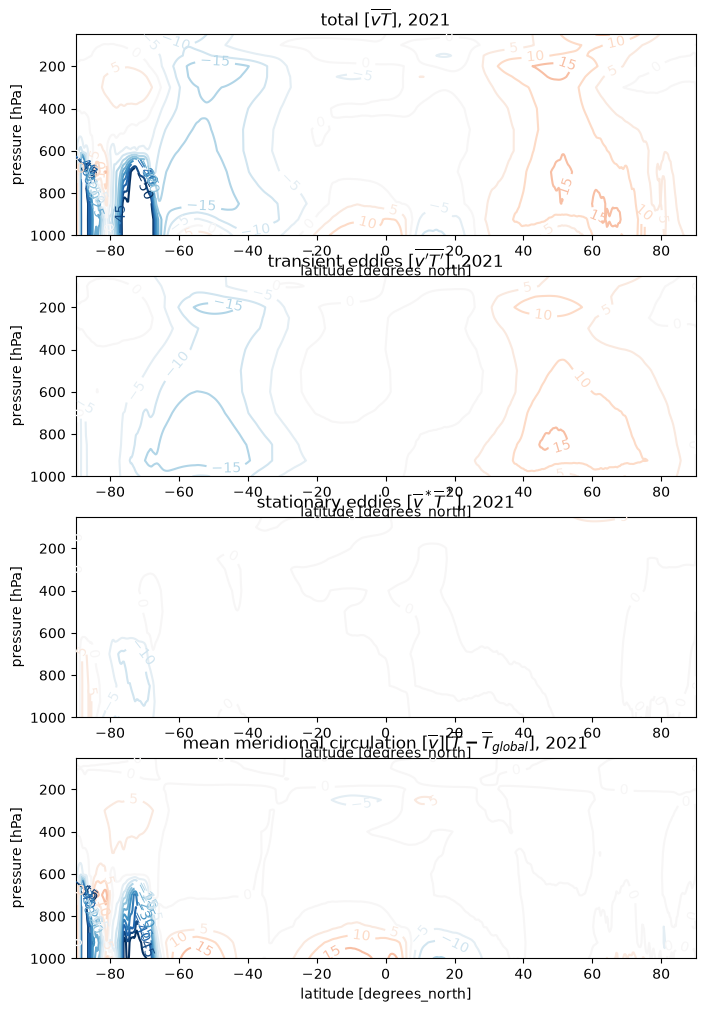

In [17]:
levs = np.arange(-50,55,5)

fig, axes = plt.subplots(4,1, figsize=(8,12))

for num, flux_name in enumerate(sensible_heat_flux):
    flux = sensible_heat_flux[flux_name]
    CS = flux.plot.contour(ax=axes[num],
                            yincrease=False, 
                            levels=levs,
                          )
    axes[num].clabel(CS)
    axes[num].set_title(flux_name + ', ' + interval)

In [16]:
dclient.close()